# Signal Research Notebook

Interactive research and development notebook for signal creation and testing.

## Workflow
1. **Load & Explore Data** - Load market data and inspect distributions
2. **Develop Signal** - Build and test signal logic interactively
3. **Implement** - Copy validated logic to `create_signal.py`
4. **Execute** - Run `uv run create-signal` to generate `data/signal.parquet`
5. **Validate Signal** - use `uv run ew-dash` to view signal characteristics.
6. **Backtest** - Use `uv run backtest` for slurm backtest on super computer
7. **Performance** - Use `uv run opt-dash` for in depth analysis of mvo backtested signal.

## Tips
- Use cells to isolate different aspects of your signal
- Modify parameters directly in cells to test variations
- Check signal statistics regularly to catch issues early
- Document your assumptions and findings as you develop

## Setup

In [2]:
import polars as pl
import numpy as np
import datetime as dt
import sf_quant.data as sfd
import sf_quant.research as sfr
import polars_ols
import matplotlib.pyplot as plt

## 1. Load & Explore Data

Load your market data and inspect key characteristics before developing the signal.

In [3]:
def load_data() -> pl.DataFrame:
    """
    Load and prepare market data for signal development.
    
    Returns:
        pl.DataFrame: Market data with required columns
    """
    # TODO: Load data from source (API, file, database)
    
    # TODO: Filter data as needed (date range, symbols, quality checks)

    # TODO: Inlcude Betas for backtester

    # EXAMPLE 
    
    start = dt.date(1929, 1, 1)
    end = dt.date(2024, 12, 31)

    # columns = [
    #     'date',
    #     'barrid',
    #     'ticker',
    #     'price',
    #     'return',
    #     'specific_return',
    #     'predicted_beta'
    # ]
    
    columns = [
        'date',
        'barrid', 'price', 'ticker', 'return', 'specific_return', 'specific_risk', 'predicted_beta'
    ]

    
    
    
    df = sfd.load_assets(
        start=start,
        end=end,
        in_universe=True,
        columns=columns
    ).filter(
        (pl.col('price')
        .shift(1)
        .gt(5))
    )
    df = df.with_columns(pl.col('date').dt.truncate('1mo').alias('month'))
    # df= df.sort(['barrid', 'month']).with_columns(pl.col('month').shift(1).over('barrid').alias(f'monthlyret'))
    df = df.sort(["barrid", "month"])
    df = df.with_columns(
    pl.col('return')
    .first()
    .over(['barrid', 'month'])
    .alias('monthreturn')
)
    return df





df = load_data()
# df.describe()
df.head()

date,barrid,price,ticker,return,specific_return,specific_risk,predicted_beta,month,monthreturn
date,str,f64,str,f64,f64,f64,f64,date,f64
2013-08-01,"""USA06Z1""",6.32,"""MDXG""",0.9585,0.365,55.028021,0.353329,2013-08-01,0.9585
2013-08-02,"""USA06Z1""",6.31,"""MDXG""",-0.1582,-0.731,54.807402,0.363624,2013-08-01,0.9585
2013-08-05,"""USA06Z1""",6.45,"""MDXG""",2.2187,1.936,54.76671,0.356596,2013-08-01,0.9585
2013-08-06,"""USA06Z1""",6.29,"""MDXG""",-2.4806,-0.528,54.692162,0.399196,2013-08-01,0.9585
2013-08-07,"""USA06Z1""",5.78,"""MDXG""",-8.1081,-7.74,55.020769,0.504134,2013-08-01,0.9585


## 2. Signal Development

Build and test your signal logic. Modify parameters and logic here to find optimal configurations.

In [4]:
def create_signal(df: pl.DataFrame) -> pl.DataFrame:
    """
    Create signal based on market data.
    
    Args:
        df: Market data DataFrame
        
    Returns:
        pl.DataFrame: DataFrame with signal column added
    """
    T=60
    days= T*21
    
    
    
    

    df = df.with_columns((pl.col('specific_return').truediv(100)).alias('specific_return')) #return space
    df = df.with_columns((pl.col('return').truediv(100)).alias('return')) #return space
    df = df.with_columns((pl.col('monthreturn').truediv(100)).alias('monthreturn'))


    df = df.with_columns(pl.col('specific_return').rolling_mean(window_size=days).over('barrid').alias('mu'))
    df = df.with_columns((pl.col('specific_return')).rolling_std(window_size=days).over('barrid').alias('iv')) 
    df = df.with_columns((((pl.col('specific_return') - pl.col('mu'))**3/pl.col('iv')**3)).over('barrid').alias('m3'))
    df = df.with_columns(pl.col('m3').rolling_sum(window_size=days).truediv(days/((days-1)*(days-2))).alias('is'))
    
   
    
    # forward fills from daily to monthly
    df = df.with_columns(pl.col("date").dt.truncate("1mo").alias("month"))

    df = df.with_columns(pl.col("is").first().over("barrid","month").alias("ismonth"))
    df = df.drop_nulls(["is", "iv", "ismonth"])
    df = df.drop(['m3', 'mu'])
    
    

    return df

signal = create_signal(df)
signal.head(100)
# signal.describe()

date,barrid,price,ticker,return,specific_return,specific_risk,predicted_beta,month,monthreturn,iv,is,ismonth
date,str,f64,str,f64,f64,f64,f64,date,f64,f64,f64,f64
2021-12-01,"""USA0C11""",98.49,"""FBHS""",-0.020292,-0.02197,17.713131,1.115648,2021-12-01,-0.020292,0.011018,1.1484e6,1.1484e6
2021-12-02,"""USA0C11""",102.49,"""FBHS""",0.040613,0.01167,17.615719,1.16297,2021-12-01,-0.020292,0.011017,1.1514e6,1.1484e6
2021-12-03,"""USA0C11""",103.73,"""FBHS""",0.012099,0.00735,17.579092,1.128883,2021-12-01,-0.020292,0.010997,1.1638e6,1.1484e6
2021-12-06,"""USA0C11""",104.05,"""FBHS""",0.003085,-0.01263,17.586405,1.119843,2021-12-01,-0.020292,0.011002,1.1619e6,1.1484e6
2021-12-07,"""USA0C11""",105.42,"""FBHS""",0.013167,-0.00113,17.570159,1.098728,2021-12-01,-0.020292,0.010994,1.1594e6,1.1484e6
…,…,…,…,…,…,…,…,…,…,…,…,…
2022-04-19,"""USA0C11""",71.73,"""FBHS""",0.040168,0.00709,16.625143,1.176218,2022-04-01,0.008347,0.011128,1.0912e6,1.0919e6
2022-04-20,"""USA0C11""",72.53,"""FBHS""",0.011153,-0.00445,16.592632,1.179387,2022-04-01,0.008347,0.011128,1.0911e6,1.0919e6
2022-04-21,"""USA0C11""",72.71,"""FBHS""",0.002482,0.00764,16.599164,1.156736,2022-04-01,0.008347,0.011128,1.0922e6,1.0919e6


In [5]:
def alphas(df):
    
    df=(df.sort('barrid', 'date')
        .with_columns(
            pl.col('specific_risk').fill_null(strategy='forward').over('barrid')
        )
        .with_columns(
            pl.col('is')
            .sub(pl.col('is').mean())
            .truediv(pl.col('is').std())
            .over('date')
            .alias('score')
        )
        .with_columns(
            pl.lit(0.05).mul('score').mul('specific_risk').alias('alpha')
        ))
    return df
alpha= alphas(signal)
alpha.head()
    

date,barrid,price,ticker,return,specific_return,specific_risk,predicted_beta,month,monthreturn,iv,is,ismonth,score,alpha
date,str,f64,str,f64,f64,f64,f64,date,f64,f64,f64,f64,f64,f64
2021-12-01,"""USA0C11""",98.49,"""FBHS""",-0.020292,-0.02197,17.713131,1.115648,2021-12-01,-0.020292,0.011018,1.1484e6,1.1484e6,0.211097,0.186959
2021-12-02,"""USA0C11""",102.49,"""FBHS""",0.040613,0.01167,17.615719,1.16297,2021-12-01,-0.020292,0.011017,1.1514e6,1.1484e6,0.210718,0.185597
2021-12-03,"""USA0C11""",103.73,"""FBHS""",0.012099,0.00735,17.579092,1.128883,2021-12-01,-0.020292,0.010997,1.1638e6,1.1484e6,0.214338,0.188394
2021-12-06,"""USA0C11""",104.05,"""FBHS""",0.003085,-0.01263,17.586405,1.119843,2021-12-01,-0.020292,0.011002,1.1619e6,1.1484e6,0.212647,0.186984
2021-12-07,"""USA0C11""",105.42,"""FBHS""",0.013167,-0.00113,17.570159,1.098728,2021-12-01,-0.020292,0.010994,1.1594e6,1.1484e6,0.213499,0.18756


In [6]:
signal= signal.with_columns(
    pl.col("ismonth").rank(method="average").over("date").alias("rank"))

signal = signal.with_columns(
    pl.count("ismonth").over("date").alias("count_per_date"))

signal = signal.with_columns(
    ((pl.col("rank") / pl.col("count_per_date") * 5).ceil().cast(pl.Int32)).alias("quintile"))

signal = signal.drop(["rank", "count_per_date"])
signal.describe()


signal= signal.filter(pl.col("quintile").is_not_null())




In [6]:
# ew = (signal.group_by(["date", "quintile"]).agg(pl.col("ismonth").mean()).pivot(
#         values="ismonth",
#         index="date",
#         columns="quintile", sort_columns=True
#     )
#     .sort("date")
#     .with_columns(pl.exclude('date')))

# dates= ew['date']

# for col in ew.columns:
#     if col != "date":
#         plt.plot(dates, ew[col], label=f"Q{col}", linewidth=0.5)

# plt.legend()
# plt.xlabel("Date")

# plt.ylabel("Firm Skewness")
# plt.title("Quintile Skewness")
# plt.show()


/tmp/ipykernel_2325133/430862856.py:5: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  ew = (signal.group_by(["date", "quintile"]).agg(pl.col("cum_ret").mean()).pivot(


shape: (4_888, 7)
┌────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ date       ┆ 1         ┆ 2         ┆ 3         ┆ 4         ┆ 5         ┆ spread    │
│ ---        ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ date       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 2005-08-01 ┆ -0.000903 ┆ 0.000644  ┆ 0.001618  ┆ 0.000565  ┆ 0.000462  ┆ -0.001365 │
│ 2005-08-02 ┆ 0.006434  ┆ 0.008091  ┆ 0.008744  ┆ 0.009237  ┆ 0.007014  ┆ -0.000581 │
│ 2005-08-03 ┆ 0.005214  ┆ 0.00711   ┆ 0.005147  ┆ 0.007201  ┆ 0.003977  ┆ 0.001237  │
│ 2005-08-04 ┆ -0.004975 ┆ -0.005679 ┆ -0.005724 ┆ -0.00548  ┆ -0.008366 ┆ 0.003391  │
│ 2005-08-05 ┆ -0.015069 ┆ -0.017174 ┆ -0.019033 ┆ -0.017517 ┆ -0.019624 ┆ 0.004555  │
│ …          ┆ …         ┆ …         ┆ …         ┆ …         ┆ …         ┆ …         │
│ 2024-12-24 ┆ 1.774987  

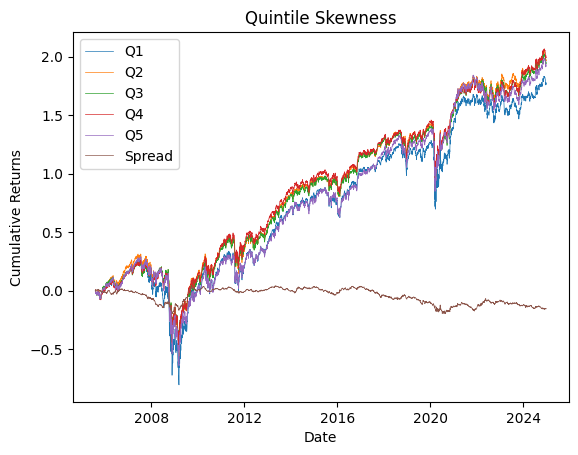

In [7]:
signal = signal.group_by(['date', 'quintile']).agg(pl.col('return').mean().alias('quint_ret')).sort(['quintile', 'date'])
signal = signal.with_columns(pl.col('quint_ret').log1p().cum_sum().over('quintile').alias('cum_ret'))


ew = (signal.group_by(["date", "quintile"]).agg(pl.col("cum_ret").mean()).pivot(
        values="cum_ret",
        index="date",
        columns="quintile", sort_columns=True
    )
    .sort("date")
    .with_columns(pl.exclude('date')))

ew = ew.with_columns((pl.col('1')-pl.col('5')).alias('spread'))
print(ew)

dates= ew['date']

for col in ew.columns:
    if col != "date" and col != 'spread':
        plt.plot(dates, ew[col], label=f"Q{col}", linewidth=0.5)
    if col == "spread":
        plt.plot(dates, ew[col], label=f"Spread", linewidth=0.5)

plt.legend()
plt.xlabel("Date")
# plt.ylim(-1,1)
plt.ylabel("Cumulative Returns")
plt.title("Quintile Skewness")
plt.show()

## 3. Signal Analysis

Examine signal statistics and distributions to understand its characteristics.

### Statistics

In [8]:
sfr.get_signal_stats(signal)

ColumnNotFoundError: unable to find column "signal"; valid columns: ["date", "quintile", "quint_ret", "cum_ret"]

### Distribution

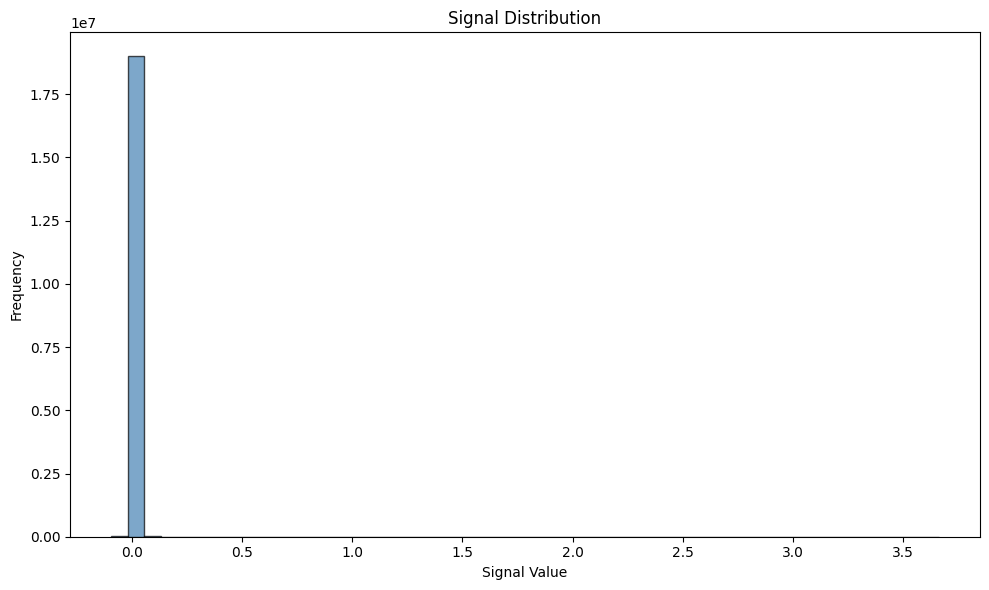

In [ ]:
sfr.get_signal_distribution(signal)

## 4. Validation Checks ?

Verify signal quality and identify any issues before implementation.

## 5. Next Steps

When satisfied with your signal:

1. **Copy** your data loading and signal calculation logic to `create_signal.py`
2. **Run** `uv run create-signal` to save the signal to `data/signal.parquet`
3. **Open** `uv run ew-dash` to analyze the signal before backtesting